# 제조 데이터 탐색 분석 종합

## 학습 목표

1. 6-10차시에서 학습한 **기술통계, 상관분석, 검정, 전처리** 기법을 **실제 복잡한 제조 데이터**에 종합 적용함 *통합 분석 역량*
2. 단순회귀분석의 한계를 인식하고, **중다회귀분석의** 필요성을 이해함 *예측 모델 기초*
3. 중다회귀 적용 시 발생하는 **다중공선성(Multicollinearity)** 문제를 진단(VIF)하고 해결 방안을 제시함 *고급 통계 진단*
4. 통계적 모델링의 한계를 인식하고 **머신러닝 도입 필요성**을 이해함 *문제 해결 확장*

### 지금까지 배운 내용 한눈에 보기

| 차시 | 주제 | 핵심 개념 | 주요 도구/수식 |
|:----:|------|----------|---------------|
| **6차시** | 기술통계량과 시각화 | 중심경향, 산포도, 분포 형태 | $\bar{x}$, $s$, 왜도, 첨도 |
| **7차시** | 상관분석 | 변수 간 선형 관계 측정 | $r = \frac{\sum(x_i-\bar{x})(y_i-\bar{y})}{(n-1)s_x s_y}$ |
| **8차시** | 가설검정 | 그룹 간 차이 통계적 판단 | t-검정, ANOVA, $p$-value |
| **9차시** | 수치형 전처리 | 결측치, 이상치, 스케일링 | SimpleImputer, StandardScaler |
| **10차시** | 범주형 전처리 | 인코딩, 파이프라인 구축 | OneHotEncoder, Pipeline |

### 전체 흐름 요약

```mermaid
flowchart TD
    subgraph PART1["Part 1: 탐색적 데이터 분석"]
        A[복잡한 제조 데이터 로드] --> B[기술통계량 분석<br/>6차시 복습]
        B --> C[다양한 시각화<br/>분포, 관계, 패턴]
        C --> D[상관분석으로<br/>핵심 변수 발견<br/>7차시 복습]
    end
    
    subgraph PART2["Part 2: 단순회귀분석"]
        D --> E[가장 상관 높은 변수로<br/>단순회귀 시도]
        E --> F[한계 발견:<br/>하나의 변수로는<br/>설명력 부족]
    end
    
    subgraph PART3["Part 3: 중다회귀분석"]
        F --> G[여러 변수를 동시에<br/>사용하면 어떨까?]
        G --> H[중다회귀분석 적용]
        H --> I[설명력 향상!<br/>그러나 새로운 문제 발생]
    end
    
    subgraph PART4["Part 4: 다중공선성"]
        I --> J[다중공선성 문제 진단<br/>VIF 계산]
        J --> K[변수 선택/제거로 해결]
        K --> L[여전히 남는 한계:<br/>비선형, 분류 문제]
    end
    
    subgraph PART5["Part 5: 머신러닝으로"]
        L --> M[머신러닝의 필요성]
        M --> N[12차시: ML 소개]
    end
    
    style PART1 fill:#e3f2fd
    style PART2 fill:#fff3e0
    style PART3 fill:#e8f5e9
    style PART4 fill:#fce4ec
    style PART5 fill:#f3e5f5
```

**왜 이 순서인가?**

| 단계 | 질문 | 답을 찾는 과정 |
|:----:|------|---------------|
| 1 | "이 데이터에서 무엇을 알 수 있을까?" | EDA와 시각화 |
| 2 | "가장 중요한 변수 하나로 예측할 수 있을까?" | 단순회귀 시도 |
| 3 | "여러 변수를 함께 쓰면 더 잘 예측할 수 있지 않을까?" | 중다회귀 도입 |
| 4 | "왜 변수를 늘렸는데 오히려 불안정해질까?" | 다중공선성 발견 |
| 5 | "선형 모델의 한계를 어떻게 극복할까?" | 머신러닝으로 전환 |

## 복잡한 제조 데이터의 도전 과제

### 실습 환경 설정

In [17]:
# 필수 라이브러리 임포트
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 시각화 설정
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.style.use('seaborn-v0_8-whitegrid')

print("라이브러리 로드 완료")

라이브러리 로드 완료


### 사용 데이터셋: SECOM 반도체 제조 데이터

SECOM 데이터셋은 **실제 반도체 제조 공정**에서 수집된 센서 데이터로, 현실 제조 환경의 복잡성을 잘 반영함.

| 특성 | 값 | 분석적 의미 |
|------|-----|------------|
| 샘플 수 | 1,567개 | 제조 공정 1회 = 1샘플 |
| 특성 수 | **590개** | 고차원(high-dimensional) 데이터 |
| 결측치 비율 | 4.54% | 센서 오류, 통신 장애 반영 |
| 타겟 변수 | Pass(-1) / Fail(1) | 품질 검사 결과 (이진 분류) |
| 클래스 비율 | Pass 93.4% / Fail 6.6% | **심각한 클래스 불균형** |

**데이터 출처**: https://archive.ics.uci.edu/ml/datasets/SECOM

**왜 이 데이터인가?**
- **현실의 복잡성**을 그대로 담고 있음
- 고차원, 결측치, 클래스 불균형, **다중공선성** 문제가 모두 존재함
- 6-10차시에서 배운 기법을 **실전 수준**으로 적용해볼 수 있음

### 데이터 로드 및 기본 탐색

In [3]:
# SECOM 데이터 로드
secom_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.data"
labels_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom_labels.data"

# 센서 데이터 (공백 구분, 헤더 없음)
df_sensors = pd.read_csv(secom_url, sep=' ', header=None)
df_sensors.columns = [f'Sensor_{i}' for i in range(df_sensors.shape[1])]

# 레이블 데이터
df_labels = pd.read_csv(labels_url, sep=' ', header=None, usecols=[0])
df_labels.columns = ['Pass_Fail']

# 병합
df = pd.concat([df_sensors, df_labels], axis=1)

print("=" * 70)
print("SECOM 반도체 제조 데이터 개요")
print("=" * 70)
print(f"데이터 크기: {df.shape[0]:,}개 샘플, {df.shape[1]:,}개 변수")
print(f"\n타겟 변수 분포:")
print(df['Pass_Fail'].value_counts())
print(f"\n불량률: {(df['Pass_Fail'] == 1).mean()*100:.2f}%")

SECOM 반도체 제조 데이터 개요
데이터 크기: 1,567개 샘플, 591개 변수

타겟 변수 분포:
Pass_Fail
-1    1463
 1     104
Name: count, dtype: int64

불량률: 6.64%


In [4]:
df.head()

,Sensor_0,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,Sensor_6,Sensor_7,Sensor_8,Sensor_9,...,Sensor_581,Sensor_582,Sensor_583,Sensor_584,Sensor_585,Sensor_586,Sensor_587,Sensor_588,Sensor_589,Pass_Fail
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


### 기술통계량 분석 (6차시 복습)

**6차시에서 배운 핵심 개념 적용**:

| 통계량 | 수식 | 의미 |
|--------|------|------|
| 평균 | $\bar{x} = \frac{1}{n}\sum_{i=1}^{n}x_i$ | 중심 경향 |
| 표준편차 | $s = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})^2}$ | 산포도 |
| 왜도 | $\gamma_1 = \frac{1}{n}\sum\left(\frac{x_i-\bar{x}}{s}\right)^3$ | 비대칭성 |
| 첨도 | $\gamma_2 = \frac{1}{n}\sum\left(\frac{x_i-\bar{x}}{s}\right)^4 - 3$ | 꼬리 두께 |


In [19]:
# 센서 변수만 추출
sensor_cols = [col for col in df.columns if col.startswith('Sensor_')]

# 기술통계량 계산 (샘플 10개 변수)
sample_sensors = sensor_cols[:10]
desc_stats = df[sample_sensors].describe().T
desc_stats['skewness'] = df[sample_sensors].skew()
desc_stats['kurtosis'] = df[sample_sensors].kurtosis()

print("=" * 70)
print("기술통계량 (샘플 10개 센서)")
print("=" * 70)
print(desc_stats.round(3))

# 타겟 변수 분포
print(f"\n타겟 변수 분포:")
print(df['Pass_Fail'].value_counts())
print(f"\n불량률: {(df['Pass_Fail'] == 1).mean()*100:.2f}%")

기술통계량 (샘플 10개 센서)
           count      mean      std       min       25%       50%       75%  \
Sensor_0  1561.0  3014.453   73.622  2743.240  2966.260  3011.490  3056.650   
Sensor_1  1560.0  2495.850   80.408  2158.750  2452.248  2499.405  2538.822   
Sensor_2  1553.0  2200.547   29.513  2060.660  2181.044  2201.067  2218.056   
Sensor_3  1553.0  1396.377  441.692     0.000  1081.876  1285.214  1591.224   
Sensor_4  1553.0     4.197   56.356     0.682     1.018     1.317     1.526   
Sensor_5  1553.0   100.000    0.000   100.000   100.000   100.000   100.000   
Sensor_6  1553.0   101.113    6.237    82.131    97.920   101.512   104.587   
Sensor_7  1558.0     0.122    0.009     0.000     0.121     0.122     0.124   
Sensor_8  1565.0     1.463    0.074     1.191     1.411     1.462     1.517   
Sensor_9  1565.0    -0.001    0.015    -0.053    -0.011    -0.001     0.008   

               max  skewness  kurtosis  
Sensor_0  3356.350     0.514     1.471  
Sensor_1  2846.440    -0.043  

### 결측치 현황 분석 (9차시 복습)

In [6]:
# 센서 컬럼만 추출
sensor_cols = [col for col in df.columns if col.startswith('Sensor_')]

# 결측치 분석
missing_count = df[sensor_cols].isna().sum()
missing_pct = df[sensor_cols].isna().sum() / len(df) * 100

# 결측 비율별 분류
print("=" * 60)
print("결측치 현황 분석")
print("=" * 60)
print(f"\n결측 비율별 변수 분포:")
print(f"  50% 이상 (제거 권장):  {(missing_pct > 50).sum()}개")
print(f"  20-50% (주의 필요):    {((missing_pct > 20) & (missing_pct <= 50)).sum()}개")
print(f"  1-20% (대체 가능):     {((missing_pct > 1) & (missing_pct <= 20)).sum()}개")
print(f"  0-1% (대체 가능):      {((missing_pct > 0) & (missing_pct <= 1)).sum()}개")
print(f"  결측 없음:             {(missing_pct == 0).sum()}개")

# 결측치 상위 10개 변수
missing_top10 = missing_pct.sort_values(ascending=False).head(10)
print(f"\n결측 비율 상위 10개 변수:")
for var, pct in missing_top10.items():
    print(f"  {var}: {pct:.1f}%")

결측치 현황 분석

결측 비율별 변수 분포:
  50% 이상 (제거 권장):  28개
  20-50% (주의 필요):    4개
  1-20% (대체 가능):     71개
  0-1% (대체 가능):      435개
  결측 없음:             52개

결측 비율 상위 10개 변수:
  Sensor_292: 91.2%
  Sensor_293: 91.2%
  Sensor_158: 91.2%
  Sensor_157: 91.2%
  Sensor_492: 85.6%
  Sensor_85: 85.6%
  Sensor_358: 85.6%
  Sensor_220: 85.6%
  Sensor_244: 65.0%
  Sensor_517: 65.0%


### 결측치 처리 및 변수 필터링

In [7]:
# 결측 비율 50% 미만인 변수만 선택 (9차시 전략 적용)
cols_to_keep = missing_pct[missing_pct < 50].index.tolist()
print(f"선택된 변수 수: {len(cols_to_keep)} / {len(sensor_cols)}")

# 분산이 0인 변수 제거 (상수 변수는 분석에 무의미)
df_filtered = df[cols_to_keep + ['Pass_Fail']].copy()
zero_var_cols = df_filtered[cols_to_keep].var() == 0
zero_var_count = zero_var_cols.sum()
print(f"분산이 0인 변수 (제거): {zero_var_count}개")

cols_to_keep = [col for col in cols_to_keep if df_filtered[col].var() > 0]
df_filtered = df[cols_to_keep + ['Pass_Fail']].copy()

# 결측치 중앙값 대체 (9차시 SimpleImputer 적용)
imputer = SimpleImputer(strategy='median')
df_filtered[cols_to_keep] = imputer.fit_transform(df_filtered[cols_to_keep])

print(f"\n최종 변수 수: {len(cols_to_keep)}개")
print(f"결측치 처리 후 결측 수: {df_filtered.isna().sum().sum()}")

선택된 변수 수: 562 / 590
분산이 0인 변수 (제거): 116개

최종 변수 수: 446개
결측치 처리 후 결측 수: 0


###다양한 시각화를 통한 데이터 탐색

**시각화의 목적**: 숫자만으로는 보이지 않는 **패턴, 이상치, 관계**를 발견함

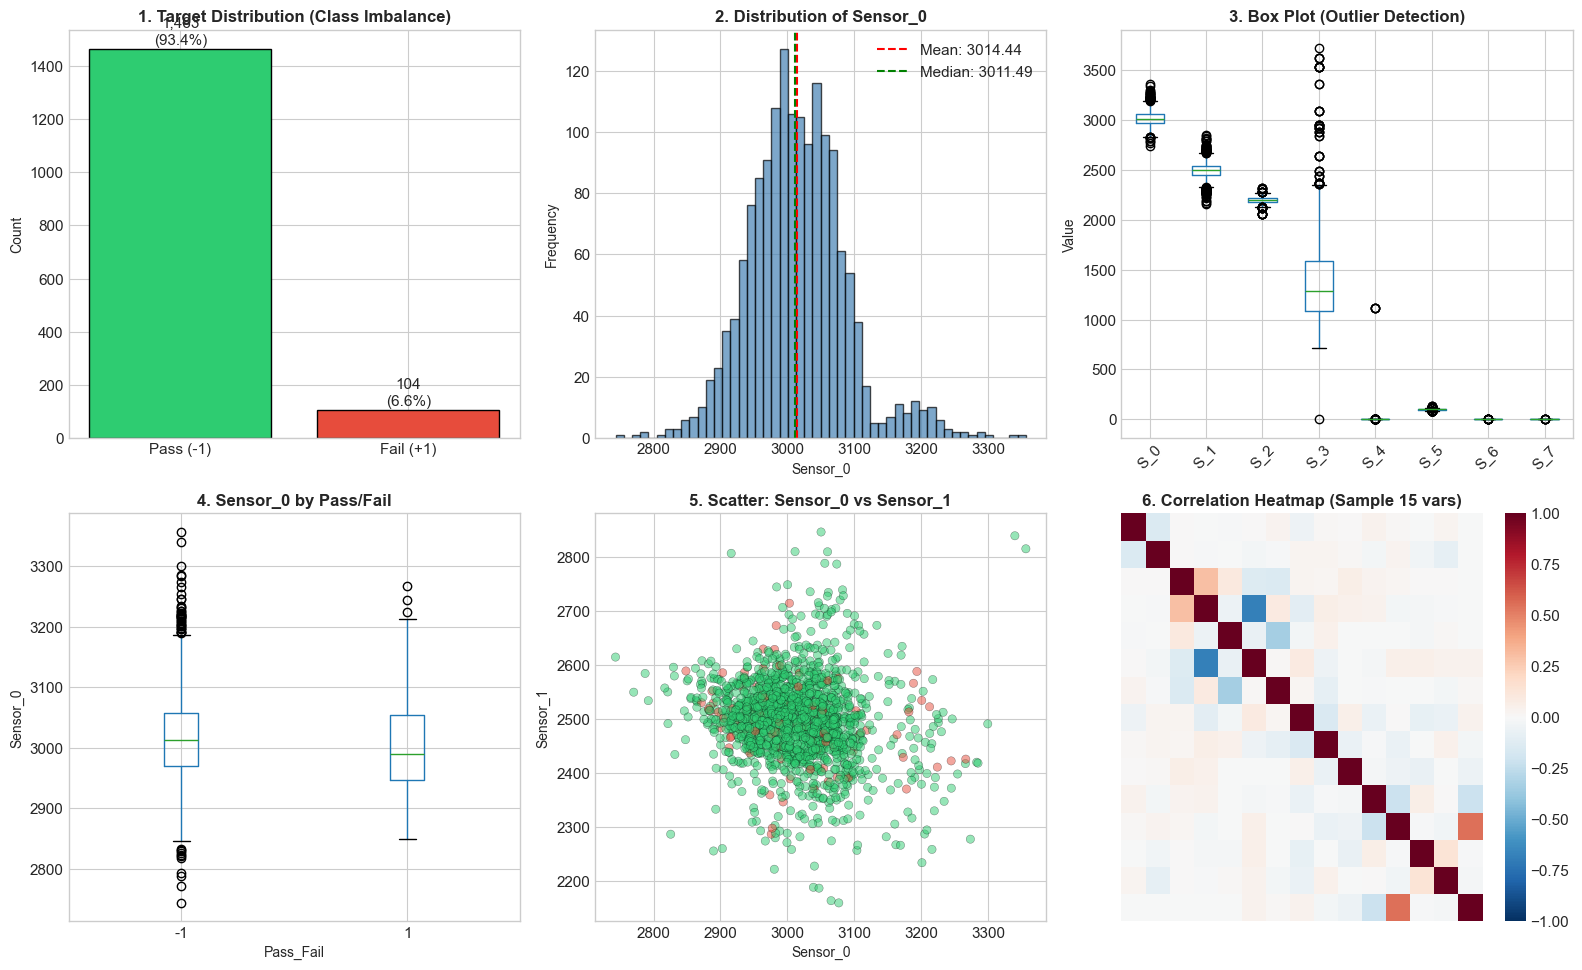

[시각화 해석]
1. 타겟 분포: Pass가 93%, Fail이 7%로 심각한 클래스 불균형
2. 센서 분포: 왜도가 있는 분포, 평균과 중앙값 차이 확인
3. 박스플롯: 여러 센서에서 이상치(점) 존재
4. 그룹 비교: Pass/Fail 간 센서값 분포 차이 탐색
5. 산점도: 두 센서 간 관계 및 클래스별 분포 확인
6. 상관 히트맵: 센서 간 상관관계 패턴 (빨강=양, 파랑=음)


In [20]:
# 1. 타겟 변수 분포 시각화
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1-1. 타겟 변수 막대그래프
target_counts = df_filtered['Pass_Fail'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0, 0].bar(['Pass (-1)', 'Fail (+1)'], target_counts.values, color=colors, edgecolor='black')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('1. Target Distribution (Class Imbalance)', fontweight='bold')
for i, v in enumerate(target_counts.values):
    axes[0, 0].text(i, v + 20, f'{v:,}\n({v/len(df_filtered)*100:.1f}%)', ha='center')

# 1-2. 샘플 센서 히스토그램
sample_sensor = cols_to_keep[0]
axes[0, 1].hist(df_filtered[sample_sensor], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 1].axvline(df_filtered[sample_sensor].mean(), color='red', linestyle='--', label=f'Mean: {df_filtered[sample_sensor].mean():.2f}')
axes[0, 1].axvline(df_filtered[sample_sensor].median(), color='green', linestyle='--', label=f'Median: {df_filtered[sample_sensor].median():.2f}')
axes[0, 1].set_xlabel(sample_sensor)
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'2. Distribution of {sample_sensor}', fontweight='bold')
axes[0, 1].legend()

# 1-3. 박스플롯 (이상치 탐지)
sample_sensors_box = cols_to_keep[:8]
df_filtered[sample_sensors_box].boxplot(ax=axes[0, 2], vert=True)
axes[0, 2].set_xticklabels([f'S_{i}' for i in range(8)], rotation=45)
axes[0, 2].set_ylabel('Value')
axes[0, 2].set_title('3. Box Plot (Outlier Detection)', fontweight='bold')

# 1-4. Pass vs Fail 그룹별 비교 박스플롯
df_filtered.boxplot(column=sample_sensor, by='Pass_Fail', ax=axes[1, 0])
axes[1, 0].set_xlabel('Pass_Fail')
axes[1, 0].set_ylabel(sample_sensor)
axes[1, 0].set_title(f'4. {sample_sensor} by Pass/Fail', fontweight='bold')
plt.suptitle('')  # 자동 생성 제목 제거

# 1-5. 두 센서 간 산점도
sensor_x, sensor_y = cols_to_keep[0], cols_to_keep[1]
scatter_colors = df_filtered['Pass_Fail'].map({-1: '#2ecc71', 1: '#e74c3c'})
axes[1, 1].scatter(df_filtered[sensor_x], df_filtered[sensor_y], 
                   c=scatter_colors, alpha=0.5, edgecolor='k', linewidth=0.3)
axes[1, 1].set_xlabel(sensor_x)
axes[1, 1].set_ylabel(sensor_y)
axes[1, 1].set_title(f'5. Scatter: {sensor_x} vs {sensor_y}', fontweight='bold')

# 1-6. 상관계수 히트맵 (샘플)
corr_sample = df_filtered[cols_to_keep[:15]].corr()
sns.heatmap(corr_sample, ax=axes[1, 2], cmap='RdBu_r', center=0, 
            vmin=-1, vmax=1, xticklabels=False, yticklabels=False)
axes[1, 2].set_title('6. Correlation Heatmap (Sample 15 vars)', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_visualization_comprehensive.png', dpi=150, bbox_inches='tight')
plt.show()

print("[시각화 해석]")
print("1. 타겟 분포: Pass가 93%, Fail이 7%로 심각한 클래스 불균형")
print("2. 센서 분포: 왜도가 있는 분포, 평균과 중앙값 차이 확인")
print("3. 박스플롯: 여러 센서에서 이상치(점) 존재")
print("4. 그룹 비교: Pass/Fail 간 센서값 분포 차이 탐색")
print("5. 산점도: 두 센서 간 관계 및 클래스별 분포 확인")
print("6. 상관 히트맵: 센서 간 상관관계 패턴 (빨강=양, 파랑=음)")

### 상관분석으로 핵심 변수 발견 (7차시 복습)

**7차시 핵심 개념**: 피어슨 상관계수

$$r_{xy} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2} \cdot \sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

| 상관계수 | 해석 |
|----------|------|
| 0.7 ~ 1.0 | 강한 양의 상관 |
| 0.3 ~ 0.7 | 중간 양의 상관 |
| -0.3 ~ 0.3 | 약한 상관 (거의 없음) |
| -0.7 ~ -0.3 | 중간 음의 상관 |
| -1.0 ~ -0.7 | 강한 음의 상관 |


In [21]:
# Pass_Fail을 숫자로 변환 (-1, 1 그대로 사용)
# 각 센서와 타겟 간 상관계수 계산
correlations_with_target = df_filtered[cols_to_keep].corrwith(df_filtered['Pass_Fail'])
correlations_sorted = correlations_with_target.abs().sort_values(ascending=False)

print("=" * 60)
print("타겟(Pass_Fail)과의 상관계수 상위 20개 변수")
print("=" * 60)
for i, (var, corr_abs) in enumerate(correlations_sorted.head(20).items(), 1):
    corr_val = correlations_with_target[var]
    direction = "+" if corr_val > 0 else "-"
    print(f"{i:2}. {var:12}: {direction}{abs(corr_val):.4f}")

# 상위 5개 변수 저장 (이후 회귀분석에 사용)
top_5_vars = correlations_sorted.head(5).index.tolist()
print(f"\n예측에 활용할 상위 5개 변수: {top_5_vars}")

타겟(Pass_Fail)과의 상관계수 상위 20개 변수
 1. Sensor_59   : +0.1560
 2. Sensor_103  : +0.1512
 3. Sensor_510  : +0.1317
 4. Sensor_348  : +0.1308
 5. Sensor_431  : +0.1199
 6. Sensor_434  : +0.1113
 7. Sensor_430  : +0.1091
 8. Sensor_21   : +0.1083
 9. Sensor_435  : +0.1083
10. Sensor_28   : -0.1070
11. Sensor_436  : +0.1061
12. Sensor_210  : +0.1033
13. Sensor_129  : +0.1028
14. Sensor_298  : +0.1017
15. Sensor_163  : +0.0995
16. Sensor_124  : +0.0942
17. Sensor_295  : +0.0914
18. Sensor_316  : -0.0894
19. Sensor_160  : +0.0892
20. Sensor_164  : +0.0873

예측에 활용할 상위 5개 변수: ['Sensor_59', 'Sensor_103', 'Sensor_510', 'Sensor_348', 'Sensor_431']


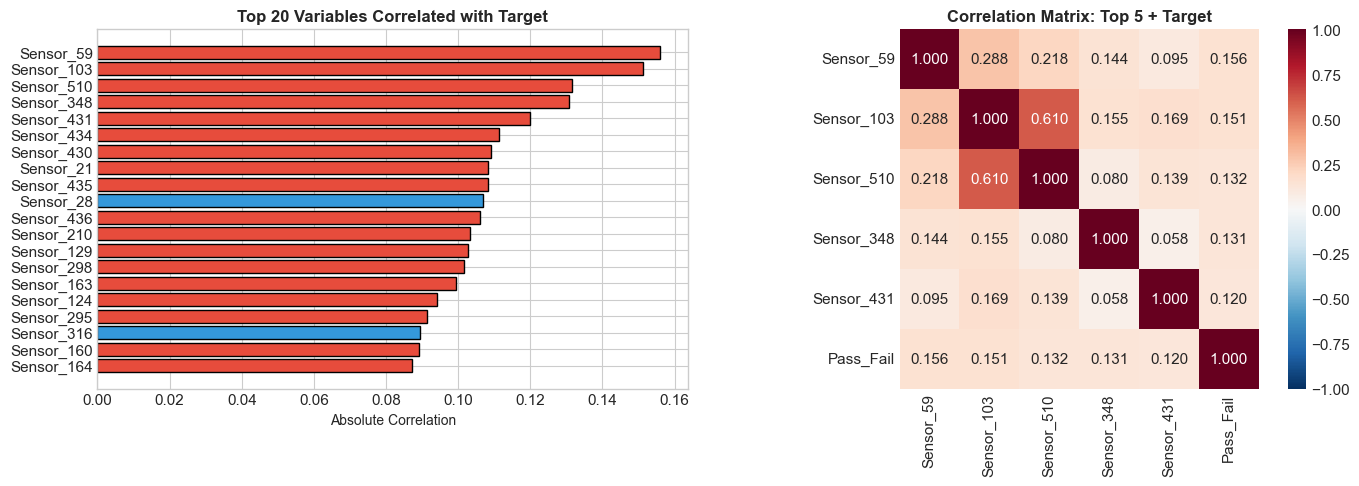

[상관분석 인사이트]
- 가장 높은 상관: Sensor_59 (r = 0.1560)
- 대부분의 센서가 타겟과 약한 상관 (|r| < 0.3)
- 이는 단일 변수로 예측이 어려움을 시사함


In [22]:
# 상위 변수들의 상관관계 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 상관계수 막대 그래프
top_20_vars = correlations_sorted.head(20).index
top_20_corrs = correlations_with_target[top_20_vars]
colors = ['#e74c3c' if c > 0 else '#3498db' for c in top_20_corrs]

axes[0].barh(range(20), top_20_corrs.abs().values, color=colors, edgecolor='black')
axes[0].set_yticks(range(20))
axes[0].set_yticklabels([f'{v[:10]}...' if len(v) > 10 else v for v in top_20_vars])
axes[0].set_xlabel('Absolute Correlation')
axes[0].set_title('Top 20 Variables Correlated with Target', fontweight='bold')
axes[0].invert_yaxis()

# 상위 5개 변수 + 타겟 상관행렬
vars_for_corr = top_5_vars + ['Pass_Fail']
corr_top5 = df_filtered[vars_for_corr].corr()
sns.heatmap(corr_top5, ax=axes[1], annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True)
axes[1].set_title('Correlation Matrix: Top 5 + Target', fontweight='bold')

plt.tight_layout()
plt.savefig('correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("[상관분석 인사이트]")
print(f"- 가장 높은 상관: {top_5_vars[0]} (r = {correlations_with_target[top_5_vars[0]]:.4f})")
print("- 대부분의 센서가 타겟과 약한 상관 (|r| < 0.3)")
print("- 이는 단일 변수로 예측이 어려움을 시사함")

## 단순회귀분석과 한계

### 상관분석에서 회귀분석으로

**7차시에서 상관분석을 배웠다면, 자연스러운 다음 질문**:

> "상관관계가 있다면, 한 변수로 다른 변수를 **예측**할 수 있지 않을까?"

이것이 바로 **회귀분석**의 출발점임.

```mermaid
flowchart LR
    A[상관분석<br/>7차시] --> B{두 변수 간<br/>관계 있음}
    B --> C[상관계수 r<br/>관계의 강도]
    B --> D[회귀분석<br/>예측 모델]
    D --> E[기울기와 절편<br/>예측 수식]
    
    style A fill:#e3f2fd
    style D fill:#e8f5e9
```

### 단순선형회귀 모델

**모델 정의**:

$$y = \beta_0 + \beta_1 x + \epsilon$$

- $\beta_0$: 절편 (x=0일 때 y의 값)
- $\beta_1$: 기울기 (x가 1 증가할 때 y의 변화량)
- $\epsilon$: 오차항

**최소제곱법(OLS)으로 계수 추정**:

$$\hat{\beta}_1 = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2} = r_{xy} \cdot \frac{s_y}{s_x}$$

$$\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}$$

**상관계수와 결정계수의 관계** (단순회귀에서):

$$R^2 = r^2$$

### 가장 상관 높은 변수로 단순회귀 시도

In [23]:
# 타겟과 가장 높은 상관을 보이는 변수로 단순회귀
best_predictor = top_5_vars[0]
print(f"최고 상관 변수: {best_predictor}")
print(f"상관계수: {correlations_with_target[best_predictor]:.4f}")

# 데이터 준비
X_simple = df_filtered[[best_predictor]].values
y = df_filtered['Pass_Fail'].values

# 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 단순회귀 모델
simple_model = LinearRegression()
simple_model.fit(X_train_scaled, y_train)

# 예측 및 평가
y_pred_train = simple_model.predict(X_train_scaled)
y_pred_test = simple_model.predict(X_test_scaled)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print("\n" + "=" * 60)
print("단순회귀분석 결과")
print("=" * 60)
print(f"사용 변수: {best_predictor}")
print(f"회귀 계수 (β1): {simple_model.coef_[0]:.4f}")
print(f"절편 (β0): {simple_model.intercept_:.4f}")
print(f"\n훈련 R²: {r2_train:.4f}")
print(f"테스트 R²: {r2_test:.4f}")

최고 상관 변수: Sensor_59
상관계수: 0.1560

단순회귀분석 결과
사용 변수: Sensor_59
회귀 계수 (β1): 0.0802
절편 (β0): -0.8723

훈련 R²: 0.0269
테스트 R²: 0.0134


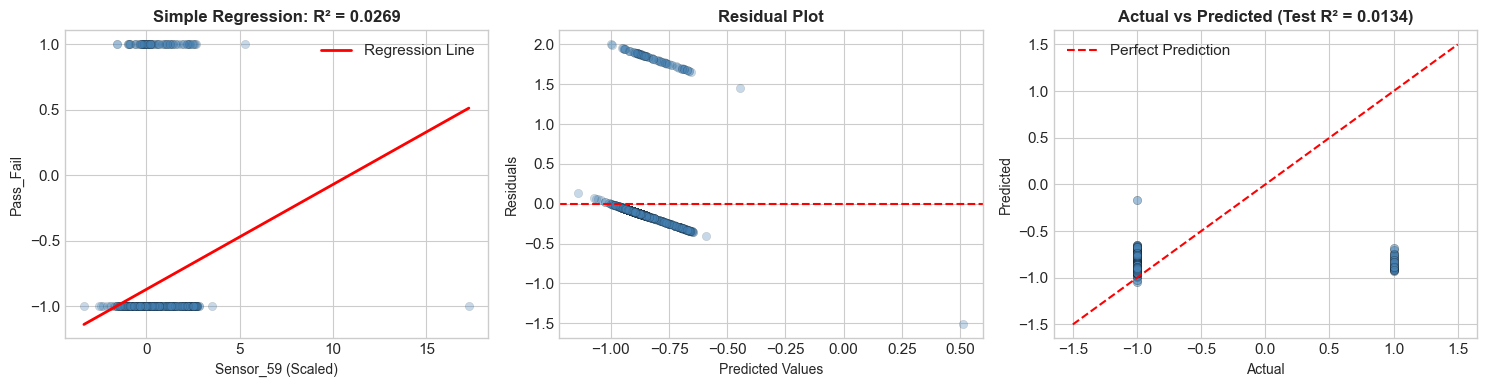


[단순회귀의 한계]
  - R² = 0.0134: 변동의 1.3%만 설명
  - 나머지 98.7%는 설명하지 못함
  - 하나의 변수만으로는 충분한 예측력을 얻기 어려움

--> 해결책: 여러 변수를 동시에 사용하는 '중다회귀분석'


In [25]:
# 단순회귀 결과 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. 데이터와 회귀선
X_plot = np.linspace(X_train_scaled.min(), X_train_scaled.max(), 100).reshape(-1, 1)
y_plot = simple_model.predict(X_plot)

axes[0].scatter(X_train_scaled, y_train, alpha=0.3, c='steelblue', edgecolor='k', linewidth=0.2)
axes[0].plot(X_plot, y_plot, 'r-', linewidth=2, label='Regression Line')
axes[0].set_xlabel(f'{best_predictor} (Scaled)')
axes[0].set_ylabel('Pass_Fail')
axes[0].set_title(f'Simple Regression: R² = {r2_train:.4f}', fontweight='bold')
axes[0].legend()

# 2. 잔차 플롯
residuals = y_train - y_pred_train
axes[1].scatter(y_pred_train, residuals, alpha=0.3, c='steelblue', edgecolor='k', linewidth=0.2)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot', fontweight='bold')

# 3. 실제 vs 예측
axes[2].scatter(y_test, y_pred_test, alpha=0.5, c='steelblue', edgecolor='k', linewidth=0.3)
axes[2].plot([-1.5, 1.5], [-1.5, 1.5], 'r--', label='Perfect Prediction')
axes[2].set_xlabel('Actual')
axes[2].set_ylabel('Predicted')
axes[2].set_title(f'Actual vs Predicted (Test R² = {r2_test:.4f})', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('simple_regression_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[단순회귀의 한계]")
print(f"  - R² = {r2_test:.4f}: 변동의 {r2_test*100:.1f}%만 설명")
print(f"  - 나머지 {(1-r2_test)*100:.1f}%는 설명하지 못함")
print("  - 하나의 변수만으로는 충분한 예측력을 얻기 어려움")
print("\n--> 해결책: 여러 변수를 동시에 사용하는 '중다회귀분석'")

## 중다회귀분석의 도입

### 단순회귀에서 중다회귀로

**단순회귀의 한계를 극복하는 자연스러운 확장**:

> "하나의 변수로 부족하다면, **여러 변수를 동시에** 사용하면 되지 않을까?"

```mermaid
flowchart LR
    subgraph 단순회귀["단순회귀 (Part 2)"]
        A["y = β₀ + β₁x₁"]
        A --> B["R² = 0.02"]
        B --> C["설명력 부족!"]
    end
    
    subgraph 중다회귀["중다회귀 (Part 3)"]
        D["y = β₀ + β₁x₁ + β₂x₂ + ... + βₚxₚ"]
        D --> E["R² = ?"]
        E --> F["설명력 향상!"]
    end
    
    C --> |"변수 추가"| D
    
    style 단순회귀 fill:#fff3e0
    style 중다회귀 fill:#e8f5e9
```

### 중다회귀분석 수학적 정의

**모델**:

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_p x_p + \epsilon$$

**행렬 표현**:

$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\epsilon}$$

여기서:
- $\mathbf{y}$: $n \times 1$ 반응변수 벡터
- $\mathbf{X}$: $n \times (p+1)$ 설계행렬 (첫 열은 1로 절편 항)
- $\boldsymbol{\beta}$: $(p+1) \times 1$ 계수 벡터

**OLS 추정량**:

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$

### 상위 5개 변수로 중다회귀 적용

In [26]:
# 상위 5개 변수로 중다회귀
X_multiple = df_filtered[top_5_vars].values
y = df_filtered['Pass_Fail'].values

# 학습/테스트 분할
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multiple, y, test_size=0.2, random_state=42
)

# 스케일링
scaler_m = StandardScaler()
X_train_m_scaled = scaler_m.fit_transform(X_train_m)
X_test_m_scaled = scaler_m.transform(X_test_m)

# 중다회귀 모델
multiple_model = LinearRegression()
multiple_model.fit(X_train_m_scaled, y_train_m)

# 예측 및 평가
y_pred_m_train = multiple_model.predict(X_train_m_scaled)
y_pred_m_test = multiple_model.predict(X_test_m_scaled)

r2_m_train = r2_score(y_train_m, y_pred_m_train)
r2_m_test = r2_score(y_test_m, y_pred_m_test)

print("=" * 60)
print("중다회귀분석 결과 (상위 5개 변수)")
print("=" * 60)
print(f"사용 변수: {top_5_vars}")
print(f"\n회귀 계수:")
for var, coef in zip(top_5_vars, multiple_model.coef_):
    print(f"  {var:12}: {coef:+.4f}")
print(f"  절편 (β0):    {multiple_model.intercept_:+.4f}")

print(f"\n훈련 R²: {r2_m_train:.4f}")
print(f"테스트 R²: {r2_m_test:.4f}")
print(f"\n단순회귀 대비 개선: {r2_m_test - r2_test:+.4f} ({(r2_m_test - r2_test)/r2_test*100:+.1f}%)")

중다회귀분석 결과 (상위 5개 변수)
사용 변수: ['Sensor_59', 'Sensor_103', 'Sensor_510', 'Sensor_348', 'Sensor_431']

회귀 계수:
  Sensor_59   : +0.0531
  Sensor_103  : +0.0318
  Sensor_510  : +0.0315
  Sensor_348  : +0.0382
  Sensor_431  : +0.0524
  절편 (β0):    -0.8723

훈련 R²: 0.0628
테스트 R²: 0.0264

단순회귀 대비 개선: +0.0130 (+96.6%)


### 오, 그럼 변수를 계속 늘려보면 되나?

In [27]:
# 변수 수를 점진적으로 늘려가며 R² 변화 관찰
n_vars_list = [1, 5, 10, 20, 30, 50, 100]
r2_results = []

for n_vars in n_vars_list:
    if n_vars > len(cols_to_keep):
        break
    
    # 상관계수 상위 n개 변수 선택
    top_n_vars = correlations_sorted.head(n_vars).index.tolist()
    X_n = df_filtered[top_n_vars].values
    
    # 분할 및 스케일링
    X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
        X_n, df_filtered['Pass_Fail'].values, test_size=0.2, random_state=42
    )
    scaler_n = StandardScaler()
    X_train_n_scaled = scaler_n.fit_transform(X_train_n)
    X_test_n_scaled = scaler_n.transform(X_test_n)
    
    # 모델 학습
    model_n = LinearRegression()
    model_n.fit(X_train_n_scaled, y_train_n)
    
    # 평가
    r2_train_n = r2_score(y_train_n, model_n.predict(X_train_n_scaled))
    r2_test_n = r2_score(y_test_n, model_n.predict(X_test_n_scaled))
    
    r2_results.append({
        'n_vars': n_vars,
        'r2_train': r2_train_n,
        'r2_test': r2_test_n
    })

r2_df = pd.DataFrame(r2_results)

print("=" * 60)
print("변수 수에 따른 R² 변화")
print("=" * 60)
print(r2_df.to_string(index=False))

변수 수에 따른 R² 변화
 n_vars  r2_train   r2_test
      1  0.026935  0.013404
      5  0.062764  0.026358
     10  0.067437  0.037062
     20  0.087869  0.052957
     30  0.101545  0.030975
     50  0.137515  0.026012
    100  0.216370 -0.016076


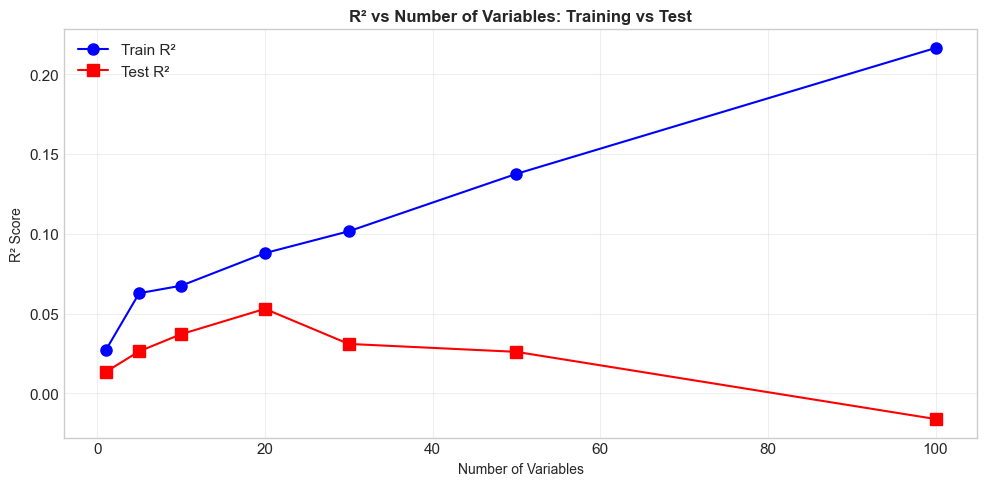


[관찰 결과]
- 변수 수가 증가하면 훈련 R²는 계속 증가
- 그러나 테스트 R²는 일정 수준에서 정체되거나 오히려 감소
- 이는 과적합(overfitting)과 다중공선성 문제를 시사함


In [28]:
# 시각화
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(r2_df['n_vars'], r2_df['r2_train'], 'bo-', label='Train R²', markersize=8)
ax.plot(r2_df['n_vars'], r2_df['r2_test'], 'rs-', label='Test R²', markersize=8)
ax.set_xlabel('Number of Variables')
ax.set_ylabel('R² Score')
ax.set_title('R² vs Number of Variables: Training vs Test', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('r2_vs_n_vars.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[관찰 결과]")
print("- 변수 수가 증가하면 훈련 R²는 계속 증가")
print("- 그러나 테스트 R²는 일정 수준에서 정체되거나 오히려 감소")
print("- 이는 과적합(overfitting)과 다중공선성 문제를 시사함")

### 중다회귀의 새로운 문제: 다중공선성

변수를 늘렸을 때 발생하는 문제를 정리하면:

```mermaid
flowchart TD
    A[변수 수 증가] --> B[훈련 R² 증가]
    A --> C[테스트 R² 정체/감소]
    A --> D[계수 불안정]
    
    C --> E[과적합<br/>Overfitting]
    D --> F[다중공선성<br/>Multicollinearity]
    
    E --> G[일반화 실패]
    F --> H[해석 불가]
    
    subgraph 문제["새로운 문제들"]
        E
        F
    end
    
    style 문제 fill:#fce4ec
```

## 다중공선성(Multicollinearity) 진단과 해결

### 다중공선성이란?

**정의**: 독립변수들 간에 **강한 선형 상관관계**가 존재하는 현상

**수학적 표현**:

다중회귀 모델에서 독립변수 $x_j$가 다른 변수들의 선형결합으로 거의 완벽히 표현될 때:

$$x_j \approx \alpha_0 + \alpha_1 x_1 + ... + \alpha_{j-1} x_{j-1} + \alpha_{j+1} x_{j+1} + ... + \alpha_p x_p$$

이 경우, 회귀 계수 $\beta_j$의 추정이 **불안정**해짐.

### 다중공선성이 야기하는 문제

| 문제 | 수학적 원인 | 실무적 결과 |
|------|-----------|------------|
| **계수 불안정** | $(X^TX)^{-1}$의 대각 원소 폭증 | 작은 데이터 변화에도 계수가 크게 변동 |
| **표준오차 증가** | $Var(\hat{\beta}_j) = \sigma^2 (X^TX)^{-1}_{jj}$ | 신뢰구간이 넓어짐 |
| **유의성 왜곡** | t-통계량 감소 | 중요한 변수도 유의하지 않게 보임 |
| **해석 곤란** | 개별 효과 분리 불가 | 어떤 변수가 진짜 영향인지 판단 어려움 |


### 상관관계 분석으로 다중공선성 탐지 (7차시 심화)

In [8]:
# 샘플 변수 50개로 상관행렬 계산 (계산 시간 고려)
sample_cols = cols_to_keep[:50]
corr_matrix = df_filtered[sample_cols].corr()

# 높은 상관관계 쌍 찾기 (|r| > 0.9)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.9:
            high_corr_pairs.append({
                'Variable_1': corr_matrix.columns[i],
                'Variable_2': corr_matrix.columns[j],
                'Correlation': round(corr_val, 4)
            })

print("=" * 60)
print("높은 상관관계 변수 쌍 (|r| > 0.9, 샘플 50개 변수)")
print("=" * 60)
if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', 
                                                              key=abs, ascending=False)
    print(high_corr_df.head(10))
else:
    print("해당 조건의 변수 쌍 없음")

높은 상관관계 변수 쌍 (|r| > 0.9, 샘플 50개 변수)
  Variable_1 Variable_2  Correlation
1  Sensor_34  Sensor_36      -1.0000
0  Sensor_25  Sensor_27       0.9804
3  Sensor_53  Sensor_54       0.9352
2  Sensor_46  Sensor_50       0.9045


In [9]:
# 전체 데이터 상관관계 분석
print("\n전체 변수 상관관계 분석 중...")
full_corr = df_filtered[cols_to_keep].corr()
high_corr_count = 0
for i in range(len(full_corr.columns)):
    for j in range(i+1, len(full_corr.columns)):
        if abs(full_corr.iloc[i, j]) > 0.9:
            high_corr_count += 1

total_pairs = len(cols_to_keep) * (len(cols_to_keep)-1) // 2
print(f"\n상관계수 |r| > 0.9인 변수 쌍: {high_corr_count:,}개")
print(f"전체 변수 쌍 수: {total_pairs:,}개")
print(f"비율: {high_corr_count / total_pairs * 100:.2f}%")


전체 변수 상관관계 분석 중...

상관계수 |r| > 0.9인 변수 쌍: 347개
전체 변수 쌍 수: 99,235개
비율: 0.35%


- SECOM 데이터에는 약 300개 이상의 높은 상관관계 쌍이 존재함
- 이는 센서들이 **유사한 물리량**을 측정하거나, **공정 특성상 연동**되기 때문임
- 이러한 다중공선성은 회귀 분석 시 심각한 문제를 야기함

### 분산팽창지수(VIF)

**VIF (Variance Inflation Factor)** 는 다중공선성을 **정량화**하는 핵심 지표임.

**수식 유도**:

변수 $x_j$를 나머지 모든 변수로 회귀했을 때:

$$x_j = \alpha_0 + \alpha_1 x_1 + ... + \alpha_{j-1} x_{j-1} + \alpha_{j+1} x_{j+1} + ... + \alpha_p x_p + \epsilon$$

이 회귀의 결정계수를 $R_j^2$라 하면:

$$VIF_j = \frac{1}{1 - R_j^2}$$

**수학적 의미**:
- $R_j^2 = 0$ (다른 변수와 무관): $VIF_j = 1$ (다중공선성 없음)
- $R_j^2 = 0.9$ (90% 설명됨): $VIF_j = 10$ (심각한 다중공선성)
- $R_j^2 \to 1$: $VIF_j \to \infty$ (완전 다중공선성)

**VIF와 계수 분산의 관계**:

$$Var(\hat{\beta}_j) = \frac{\sigma^2}{(n-1) \cdot Var(x_j)} \cdot VIF_j$$

즉, **VIF가 클수록 계수 추정의 분산이 VIF배만큼 증가**함.

**해석 기준**:

| VIF 값 | 해석 | 조치 |
|--------|------|------|
| 1 | 다중공선성 없음 | 문제없음 |
| 1-5 | 낮은 다중공선성 | 허용 가능 |
| 5-10 | 중간 다중공선성 | 주의 필요 |
| **10 이상** | **높은 다중공선성** | **조치 필요** |

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF 계산 (계산 시간 고려하여 30개 변수로 제한)
vif_cols = cols_to_keep[:30]
X_vif = df_filtered[vif_cols].values

# VIF 계산
vif_data = []
print("VIF 계산 중...")
for i in range(X_vif.shape[1]):
    vif_value = variance_inflation_factor(X_vif, i)
    vif_data.append({
        'Variable': vif_cols[i],
        'VIF': round(vif_value, 2)
    })

vif_df = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

print("=" * 60)
print("분산팽창지수(VIF) 분석 결과 (상위 30개 변수)")
print("=" * 60)
print(vif_df.head(15))

print(f"\n요약:")
print(f"  VIF > 10 (심각): {(vif_df['VIF'] > 10).sum()}개")
print(f"  VIF 5-10 (주의): {((vif_df['VIF'] >= 5) & (vif_df['VIF'] <= 10)).sum()}개")
print(f"  VIF < 5 (양호):  {(vif_df['VIF'] < 5).sum()}개")

VIF 계산 중...
분산팽창지수(VIF) 분석 결과 (상위 30개 변수)
     Variable         VIF
11  Sensor_12  5684818.65
16  Sensor_18  5139405.88
10  Sensor_11    19490.29
15  Sensor_17    19449.52
14  Sensor_16    14791.09
18  Sensor_20     5936.72
2    Sensor_2     5680.00
17  Sensor_19     3216.61
23  Sensor_25     2135.60
24  Sensor_26     1696.78
0    Sensor_0     1682.67
1    Sensor_1      988.33
25  Sensor_27      878.20
26  Sensor_28      760.14
13  Sensor_15      582.54

요약:
  VIF > 10 (심각): 25개
  VIF 5-10 (주의): 1개
  VIF < 5 (양호):  4개


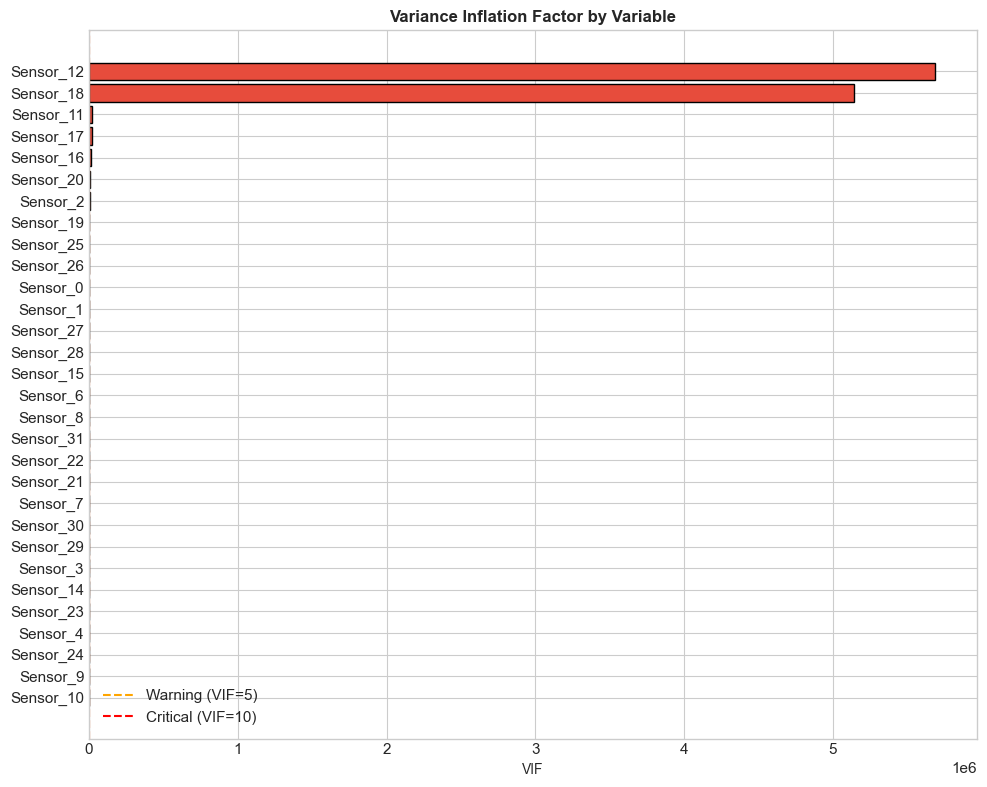

In [29]:
# VIF 시각화
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v > 10 else '#f39c12' if v > 5 else '#2ecc71' for v in vif_df['VIF']]
ax.barh(vif_df['Variable'], vif_df['VIF'], color=colors, edgecolor='black')
ax.axvline(x=5, color='orange', linestyle='--', label='Warning (VIF=5)')
ax.axvline(x=10, color='red', linestyle='--', label='Critical (VIF=10)')
ax.set_xlabel('VIF')
ax.set_title('Variance Inflation Factor by Variable', fontweight='bold')
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('vif_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 다중공선성 해결 전략

| 방법 | 설명 | 장점 | 단점 |
|------|------|------|------|
| **상관관계 기반 제거** | \|r\| > 0.9인 쌍에서 하나 제거 | 단순, 빠름 | 정보 손실 |
| **VIF 기반 순차 제거** | VIF > 10인 변수 반복 제거 | 체계적 | 반복 계산 필요 |
| **주성분 분석(PCA)** | 상관된 변수를 주성분으로 변환 | 차원 축소 | 해석 어려움 |
| **정규화 회귀 (Ridge/Lasso)** | 페널티로 계수 크기 제한 | 모든 변수 유지 | 하이퍼파라미터 필요 |

In [31]:
def remove_high_vif(X_df, threshold=10):
    """
    VIF > threshold인 변수를 순차적으로 제거
    """
    cols = X_df.columns.tolist()
    removed = []
    
    while True:
        X = X_df[cols].values
        vifs = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
        max_vif = max(vifs)
        
        if max_vif <= threshold:
            break
        
        max_idx = vifs.index(max_vif)
        removed_col = cols.pop(max_idx)
        removed.append((removed_col, max_vif))
        print(f"Removed: {removed_col} (VIF = {max_vif:.2f})")
    
    return cols, removed

# VIF 기반 변수 제거
print("=" * 60)
print("VIF 기반 변수 제거 (threshold = 10)")
print("=" * 60)
remaining_cols, removed_cols = remove_high_vif(df_filtered[top_20_vars], threshold=10)

print(f"\n제거된 변수 수: {len(removed_cols)}")
print(f"남은 변수 수: {len(remaining_cols)}")

VIF 기반 변수 제거 (threshold = 10)
Removed: Sensor_434 (VIF = 1938.68)
Removed: Sensor_160 (VIF = 880.55)
Removed: Sensor_124 (VIF = 753.36)
Removed: Sensor_298 (VIF = 262.85)
Removed: Sensor_435 (VIF = 206.83)
Removed: Sensor_28 (VIF = 179.25)
Removed: Sensor_431 (VIF = 149.03)
Removed: Sensor_210 (VIF = 56.96)
Removed: Sensor_21 (VIF = 45.02)
Removed: Sensor_316 (VIF = 21.72)
Removed: Sensor_163 (VIF = 15.57)
Removed: Sensor_436 (VIF = 14.17)

제거된 변수 수: 12
남은 변수 수: 8


In [32]:
# 다중공선성 해결 후 중다회귀
X_clean = df_filtered[remaining_cols].values
y_clean = df_filtered['Pass_Fail'].values

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

model_clean = LinearRegression()
model_clean.fit(X_train_c_scaled, y_train_c)

r2_clean_train = r2_score(y_train_c, model_clean.predict(X_train_c_scaled))
r2_clean_test = r2_score(y_test_c, model_clean.predict(X_test_c_scaled))

print("=" * 60)
print("다중공선성 해결 후 중다회귀 결과")
print("=" * 60)
print(f"사용 변수 수: {len(remaining_cols)}개")
print(f"\n훈련 R²: {r2_clean_train:.4f}")
print(f"테스트 R²: {r2_clean_test:.4f}")

다중공선성 해결 후 중다회귀 결과
사용 변수 수: 8개

훈련 R²: 0.0639
테스트 R²: 0.0354


### 다중공선성 해결 후 중다회귀 재적용

In [33]:
# 다중공선성 해결 후 중다회귀
X_clean = df_filtered[remaining_cols].values
y_clean = df_filtered['Pass_Fail'].values

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

model_clean = LinearRegression()
model_clean.fit(X_train_c_scaled, y_train_c)

r2_clean_train = r2_score(y_train_c, model_clean.predict(X_train_c_scaled))
r2_clean_test = r2_score(y_test_c, model_clean.predict(X_test_c_scaled))

print("=" * 60)
print("다중공선성 해결 후 중다회귀 결과")
print("=" * 60)
print(f"사용 변수 수: {len(remaining_cols)}개")
print(f"\n훈련 R²: {r2_clean_train:.4f}")
print(f"테스트 R²: {r2_clean_test:.4f}")

# 비교 정리
print("\n" + "=" * 60)
print("회귀분석 결과 비교")
print("=" * 60)
comparison = pd.DataFrame({
    'Model': ['Simple (1 var)', 'Multiple (5 vars)', 'Multiple (20 vars)', f'VIF-cleaned ({len(remaining_cols)} vars)'],
    'Train R²': [r2_train, r2_m_train, r2_results[-1]['r2_train'] if len(r2_results) > 3 else np.nan, r2_clean_train],
    'Test R²': [r2_test, r2_m_test, r2_results[-1]['r2_test'] if len(r2_results) > 3 else np.nan, r2_clean_test]
})
print(comparison.to_string(index=False))

다중공선성 해결 후 중다회귀 결과
사용 변수 수: 8개

훈련 R²: 0.0639
테스트 R²: 0.0354

회귀분석 결과 비교
               Model  Train R²   Test R²
      Simple (1 var)  0.026935  0.013404
   Multiple (5 vars)  0.062764  0.026358
  Multiple (20 vars)  0.216370 -0.016076
VIF-cleaned (8 vars)  0.063904  0.035445


### 전체 흐름 정리

```mermaid
flowchart TD
    subgraph 탐색["Part 1: EDA"]
        A[데이터 로드] --> B[기술통계/시각화]
        B --> C[상관분석]
        C --> D[핵심 변수 발견]
    end
    
    subgraph 단순["Part 2: 단순회귀"]
        D --> E[최고 상관 변수 1개]
        E --> F[단순회귀 적용]
        F --> G[R² ≈ 0.02<br/>설명력 부족]
    end
    
    subgraph 중다["Part 3: 중다회귀"]
        G --> H[변수 5개 사용]
        H --> I[R² 향상]
        I --> J[변수 더 추가?]
        J --> K[훈련 R² ↑<br/>테스트 R² 정체]
    end
    
    subgraph 공선성["Part 4: 다중공선성"]
        K --> L[VIF 진단]
        L --> M{VIF > 10?}
        M -->|Yes| N[해당 변수 제거]
        N --> L
        M -->|No| O[안정적인 모델]
    end
    
    subgraph 한계["Part 5: 한계"]
        O --> P[여전히 낮은 R²]
        P --> Q[비선형 관계 미포착]
        Q --> R[분류 문제에 부적합]
        R --> S[머신러닝 필요!]
    end
    
    style 탐색 fill:#e3f2fd
    style 단순 fill:#fff3e0
    style 중다 fill:#e8f5e9
    style 공선성 fill:#fce4ec
    style 한계 fill:#f3e5f5
```

#### [한계 1] 설명력의 한계
  - 최종 테스트 R²: {r2_clean_test:.4f}
  - 변동의 {r2_clean_test*100:.1f}%만 설명 가능
  - 나머지 {(1-r2_clean_test)*100:.1f}%는 모델이 포착하지 못하는 패턴

#### [한계 2] 비선형 관계 포착 불가
  - 선형 회귀: y = β₀ + β₁x₁ + β₂x₂ + ...
  - x², log(x), x₁·x₂ 등 비선형/상호작용 효과 미포착
  --> 의사결정나무, 신경망은 자동으로 비선형 학습

#### [한계 3] 분류 문제 적용 어려움
  - SECOM의 타겟: Pass(-1) / Fail(+1) → 분류 문제
  - 선형 회귀로는 연속값 예측만 가능
  --> 로지스틱 회귀, Random Forest 등 분류 알고리즘 필요

#### [한계 4] 클래스 불균형 처리 어려움
  - Pass 93% / Fail 7%
  - 단순히 Pass만 예측해도 정확도 93%
  --> 불균형 처리 기법 (SMOTE, class_weight) 필요

### 통계 분석 vs 머신러닝

| 구분 | 통계적 접근 (6-11차시) | 머신러닝 (12차시~) |
|------|----------------------|-------------------|
| **목적** | 변수 간 **관계 이해** | **예측 성능** 최적화 |
| **가정** | 정규성, 선형성 등 가정 필요 | 가정 최소화 |
| **비선형** | 수동 변환 필요 | **자동 학습** |
| **고차원** | 다중공선성 문제 | 정규화, 앙상블로 극복 |
| **해석** | 계수로 인과관계 추론 | 블랙박스 경향 (해석 기법 별도) |


## 핵심 정리

### 이번 차시에서 배운 흐름

| 단계 | 핵심 질문 | 해결 도구 | 결과 |
|:----:|----------|----------|------|
| 1 | 데이터에서 무엇을 발견할 수 있나? | EDA, 시각화, 상관분석 | 핵심 변수 발견 |
| 2 | 하나의 변수로 예측 가능? | 단순회귀 | R² ≈ 2% (부족) |
| 3 | 여러 변수를 쓰면? | 중다회귀 | R² 향상, 그러나... |
| 4 | 왜 불안정해지나? | VIF 진단 | 다중공선성 발견 |
| 5 | 그래도 한계가 있다면? | - | 머신러닝 도입 |

### 다중공선성 체크리스트

| 진단 방법 | 기준 | 조치 |
|----------|------|------|
| 상관계수 | \|r\| > 0.9 | 쌍 중 하나 제거 |
| VIF | > 10 | 해당 변수 제거 |
| VIF | 5-10 | 주의 관찰 |

### 6-11차시 통합 파이프라인

```mermaid
flowchart TD
    A[원본 데이터] --> B[결측치/이상치 처리<br/>9차시]
    B --> C[기술통계량<br/>6차시]
    C --> D[시각화<br/>6차시]
    D --> E[상관분석<br/>7차시]
    E --> F[통계 검정<br/>8차시]
    F --> G[스케일링<br/>9차시]
    G --> H[인코딩<br/>10차시]
    H --> I[다중공선성 진단<br/>11차시]
    I --> J[회귀분석<br/>11차시]
    J --> K[머신러닝<br/>12차시]
    
    style I fill:#fce4ec
    style J fill:#fce4ec
    style K fill:#e3f2fd
```

## 심화 주제

### 조정 결정계수 ($R^2_{adj}$)

변수 수가 증가하면 $R^2$는 항상 증가함. 이를 보정하기 위해:

$$R^2_{adj} = 1 - \frac{(1-R^2)(n-1)}{n-p-1}$$

- $n$: 샘플 수
- $p$: 변수 수

무의미한 변수 추가 시 $R^2_{adj}$는 **감소**할 수 있음.

### 잔차 분석 4가지 가정

| 가정 | 검토 방법 | 위반 시 |
|------|----------|--------|
| 선형성 | 잔차 vs 예측값 플롯 | 비선형 패턴 → 변환 필요 |
| 등분산성 | 잔차 분산 일정 | 깔때기 모양 → 가중회귀 |
| 정규성 | Q-Q plot | 비정규 → 변환 또는 부트스트랩 |
| 독립성 | 잔차 간 상관 없음 | 자기상관 → 시계열 모델 |

### Ridge/Lasso 회귀 (정규화)

다중공선성 해결의 또 다른 방법:

**Ridge 회귀 (L2 정규화)**:
$$\min_{\beta} \sum(y_i - \hat{y}_i)^2 + \lambda \sum \beta_j^2$$

**Lasso 회귀 (L1 정규화)**:
$$\min_{\beta} \sum(y_i - \hat{y}_i)^2 + \lambda \sum |\beta_j|$$

Lasso는 일부 계수를 0으로 만들어 **자동 변수 선택** 효과가 있음.